# Daily Bike Rentals — Decision Tree Regression (Clean Dataset)
This notebook trains a **Decision Tree Regressor** model on the cleaned dataset.

Features used: `season`, `mnth`, `weathersit`, `temp`, `hum`, `windspeed`.
The `yr` column is removed to prevent data leakage.

## 1) Imports & Setup

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ⚙️ Set your dataset path
DATA_PATH = r"C:\Users\koran\Desktop\Semester 3 AI Machine Learning and Data\Individual Challenges\First Individual Challenge\DAIA\data\processed\bike_daily_clean.csv"


## 2) Load and Inspect Data

In [43]:
df = pd.read_csv(DATA_PATH)

if "dteday" in df.columns:
    df["dteday"] = pd.to_datetime(df["dteday"], errors="coerce")

if "yr" in df.columns:
    df.drop(columns="yr", inplace=True)

print("Data Loaded Successfully")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head(5))


Data Loaded Successfully
Shape: (731, 20)
Columns: ['temp', 'hum', 'windspeed', 'cnt', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12']


,temp,hum,windspeed,cnt,season_2,season_3,season_4,weathersit_2,weathersit_3,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12
0,0.344167,0.805833,0.160446,985,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,0.363478,0.696087,0.248539,801,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,0.196364,0.437273,0.248309,1349,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0.200000,0.590435,0.160296,1562,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0.226957,0.436957,0.186900,1600,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 3) Prepare Features and Train/Test Split (80/20)

In [44]:
y = df["cnt"].values
X = df.drop(columns=["cnt", "dteday"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Feature columns:", list(X.columns))


Train shape: (584, 19) | Test shape: (147, 19)
Feature columns: ['temp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12']


## 4) Build and Tune Decision Tree Model

In [45]:
categorical, numeric = [], []
for c in X_train.columns:
    if X_train[c].dtype.kind in "bifc":
        numeric.append(c)
    else:
        categorical.append(c)

for c in ["season", "mnth", "weathersit"]:
    if c in X_train.columns:
        if c in numeric: numeric.remove(c)
        if c not in categorical: categorical.append(c)

numeric = [c for c in numeric if c not in categorical]

prep = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
])

tree = DecisionTreeRegressor(random_state=42)

pipe = Pipeline([
    ("prep", prep),
    ("model", tree)
])

param_grid = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

print(" Running GridSearchCV...")
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV R²:", round(grid.best_score_, 3))


 Running GridSearchCV...
Best Parameters: {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV R²: 0.512


## 5) Evaluate on Test Set

In [46]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n📊 Decision Tree — Test Results")
print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.3f}")



📊 Decision Tree — Test Results
RMSE: 1403.401 | MAE: 1187.480 | R²: 0.509


## 6) Residual Plot

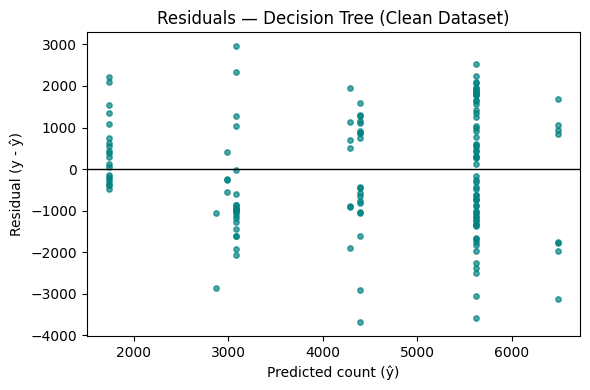

In [47]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, s=15, alpha=0.7, color='teal')
plt.axhline(0, color='black', lw=1)
plt.xlabel("Predicted count (ŷ)")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals — Decision Tree (Clean Dataset)")
plt.tight_layout()
plt.show()


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# --- Feature separation (numeric / categorical) ---
categorical, numeric = [], []
for c in X_train.columns:
    if X_train[c].dtype.kind in "bifc":
        numeric.append(c)
    else:
        categorical.append(c)

# Move known categorical features explicitly
for c in ["season", "mnth", "weathersit"]:
    if c in X_train.columns:
        if c in numeric: numeric.remove(c)
        if c not in categorical: categorical.append(c)

numeric = [c for c in numeric if c not in categorical]

# --- Preprocessor ---
prep = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
])

# --- Model ---
rf = RandomForestRegressor(random_state=42)

pipe = Pipeline([
    ("prep", prep),
    ("model", rf)
])

# --- Hyperparameter grid ---
param_grid = {
    "model__n_estimators": [100, 200, 300],       # number of trees
    "model__max_depth": [5, 10, 15, None],        # depth of each tree
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["auto", "sqrt", "log2"]
}

print(" Running GridSearchCV for RandomForest...")
grid = GridSearchCV(pipe, param_grid, cv=5, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV R²:", round(grid.best_score_, 3))


 Running GridSearchCV for RandomForest...


c:\Users\koran\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
540 fits failed out of a total of 1620.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
326 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\koran\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\koran\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\koran\Ap

Best Parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV R²: 0.598
